№7 (3 балла)
С сайта https://www.kaggle.com/ скачайте датасет на ваш выбор для обучения модели
логистической регрессии (задача классификации). Выполните следующие действия:
1. Опишите выбранный набор данных: контекст данных, какие данные есть в наборе,
как можно будет использовать полученные результаты классификации.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

df = pd.read_csv("titanic.csv")

# Удаляем ненужные колонки
df = df.drop(["PassengerId", "Name", "Ticket", "Cabin"], axis=1)

# Заполняем пропуски
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# OHE
df = pd.get_dummies(df, drop_first=True)

df.head()


,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,True,True,False
1,1,3,47.0,1,0,7.0000,False,False,True
2,0,2,62.0,0,0,9.6875,True,True,False
3,0,3,27.0,0,0,8.6625,True,False,True
4,1,3,22.0,1,1,12.2875,False,False,True


2. Постройте классификацию, используя логистическую регрессионную модель.
Оцените качество работы модели.


In [63]:
X_plot = df[["Age", "Fare"]]
y_plot = df["Survived"]

scaler = StandardScaler()
X_plot_scaled = scaler.fit_transform(X_plot)

logreg = LogisticRegression(solver='liblinear')
logreg.fit(X_plot_scaled, y_plot)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


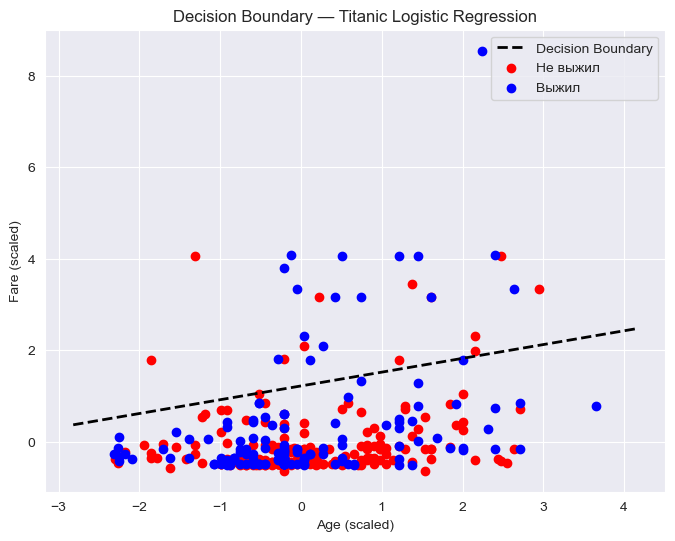

In [64]:
b = logreg.intercept_[0]
w1, w2 = logreg.coef_[0]

m = -w1 / w2
c = -b / w2

xmin, xmax = X_plot_scaled[:,0].min() - 0.5, X_plot_scaled[:,0].max() + 0.5
xd = np.linspace(xmin, xmax, 100)
yd = m * xd + c

class0 = X_plot_scaled[y_plot==0]
class1 = X_plot_scaled[y_plot==1]

plt.figure(figsize=(8,6))
plt.plot(xd, yd, 'k--', lw=2, label="Decision Boundary")

plt.scatter(class0[:,0], class0[:,1], c='red', label="Не выжил")
plt.scatter(class1[:,0], class1[:,1], c='blue', label="Выжил")

plt.xlabel("Age (scaled)")
plt.ylabel("Fare (scaled)")
plt.title("Decision Boundary — Titanic Logistic Regression")
plt.legend()
plt.grid(True)
plt.show()


In [65]:
y_pred = logreg.predict(X_plot_scaled)
cm = confusion_matrix(y_plot, y_pred)
cm

array([[254,  12],
       [136,  16]], dtype=int64)

In [66]:
print("Accuracy:", accuracy_score(y_plot, y_pred))
print("Precision:", precision_score(y_plot, y_pred))
print("Recall:", recall_score(y_plot, y_pred))
print("F1:", f1_score(y_plot, y_pred))


Accuracy: 0.645933014354067
Precision: 0.5714285714285714
Recall: 0.10526315789473684
F1: 0.17777777777777778


3. Спрогнозируйте несколько новых значений с помощью построенной модели.

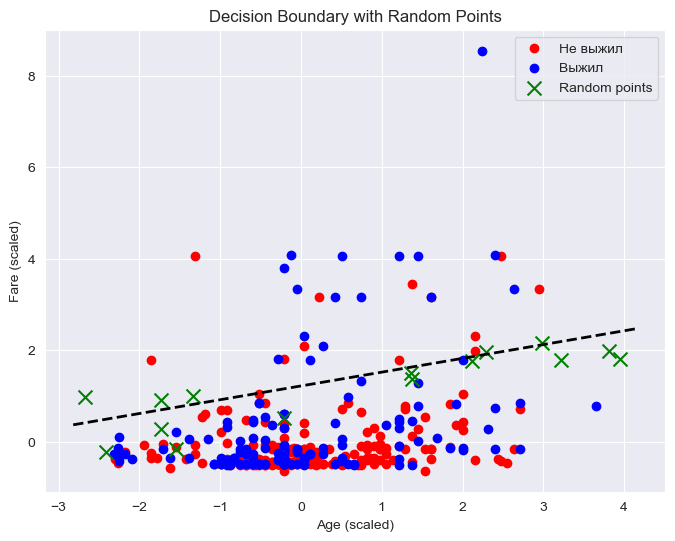

Random point 1: predicted class = 0
Random point 2: predicted class = 0
Random point 3: predicted class = 1
Random point 4: predicted class = 0
Random point 5: predicted class = 0
Random point 6: predicted class = 1
Random point 7: predicted class = 0
Random point 8: predicted class = 0
Random point 9: predicted class = 0
Random point 10: predicted class = 0
Random point 11: predicted class = 1
Random point 12: predicted class = 0
Random point 13: predicted class = 1
Random point 14: predicted class = 1
Random point 15: predicted class = 0


In [67]:
num_points = 15
np.random.seed(42)

x_rand = np.random.uniform(xmin, xmax, num_points)
y_rand = m * x_rand + c + np.random.uniform(-1, 1, num_points)

random_points = np.column_stack((x_rand, y_rand))

pred_classes = logreg.predict(random_points)

plt.figure(figsize=(8,6))
plt.plot(xd, yd, 'k--', lw=2)

plt.scatter(class0[:,0], class0[:,1], c='red', label="Не выжил")
plt.scatter(class1[:,0], class1[:,1], c='blue', label="Выжил")

plt.scatter(random_points[:,0], random_points[:,1], c='green', marker='x', s=100, label="Random points")

plt.xlabel("Age (scaled)")
plt.ylabel("Fare (scaled)")
plt.title("Decision Boundary with Random Points")
plt.legend()
plt.grid(True)
plt.show()

for i, cls in enumerate(pred_classes):
    print(f"Random point {i+1}: predicted class = {cls}")
